<a href="https://colab.research.google.com/github/Neha2580/Telco_churn_Analysis/blob/main/churn_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()


Saving customerChurn.csv to customerChurn.csv


In [ ]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install numpy

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('customerChurn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Inspection of data**


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


As we can see here MonthlyCharges are in float datatype so totalcharges should also be in float but it's in object , if we see the data in excel then we get to know that some of the rows of totalcharges are blank that's why its happening


In [5]:
#replacing blanks with 0 as tenure is 0 and no total charges are required


In [5]:
df['TotalCharges'] = df['TotalCharges'].replace(" ","0")
df['TotalCharges'] = df['TotalCharges'].astype("float")


In [22]:
df['TotalCharges'].unique()

array([  29.85, 1889.5 ,  108.15, ...,  346.45,  306.6 , 6844.5 ])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [10]:
df.duplicated().sum()

0

When checking for duplicates, it’s important to look at specific columns as well. It’s possible that the same ID might have different associated information across records, which is why they may not be flagged as duplicates.

In [11]:
df['customerID'].duplicated().sum()

0

In [12]:
def conv(value):
  if value == 1:
    return "Yes"
  else:
    return "No"

df['SeniorCitizen']   = df['SeniorCitizen'].apply(conv)


converted 0 and 1 of seniorcitizen coloum to yes or no

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

**one hot encoding**

In [16]:
df_encoded = pd.get_dummies(df, columns=['Contract'])
df_encoded

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Contract_Month-to-month,Contract_One year,Contract_Two year
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Yes,Electronic check,29.85,29.85,No,True,False,False
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,Mailed check,56.95,1889.50,No,False,True,False
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Yes,Mailed check,53.85,108.15,Yes,True,False,False
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,No,Bank transfer (automatic),42.30,1840.75,No,False,True,False
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Yes,Electronic check,70.70,151.65,Yes,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Mailed check,84.80,1990.50,No,False,True,False
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Credit card (automatic),103.20,7362.90,No,False,True,False
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,Yes,Electronic check,29.60,346.45,No,True,False,False
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,Yes,Mailed check,74.40,306.60,Yes,True,False,False


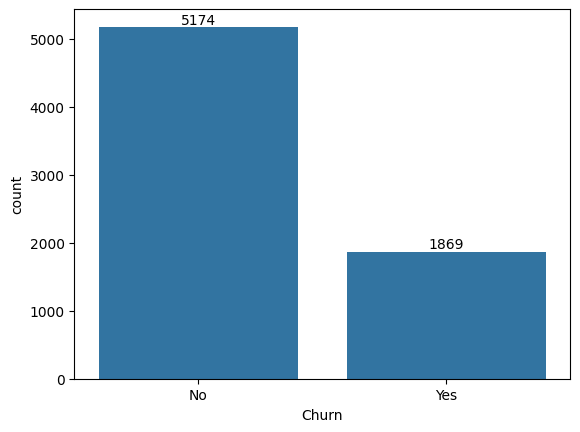

In [14]:
ax = sns.countplot(x=df['Churn'], data = df)
ax.bar_label(ax.containers[0])
plt.show()

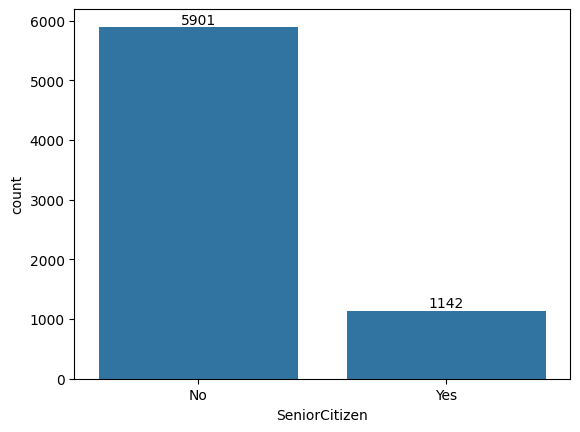

In [23]:
ax = sns.countplot(x=df['SeniorCitizen'], data = df)
ax.bar_label(ax.containers[0])
plt.show()

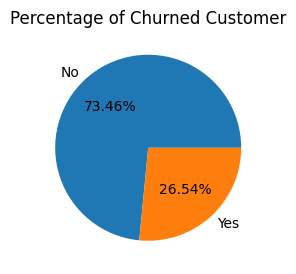

In [15]:
plt.figure(figsize= (3,4))
gb = df.groupby("Churn").agg({'Churn':"count"})
gb
plt.pie(gb['Churn'], labels = gb.index , autopct = "%1.2f%%")
plt.title("Percentage of Churned Customer")
plt.show()

from the given pie chart we can conclude that 26.54% of our customers have churned out.  now let's explore the reason behind it

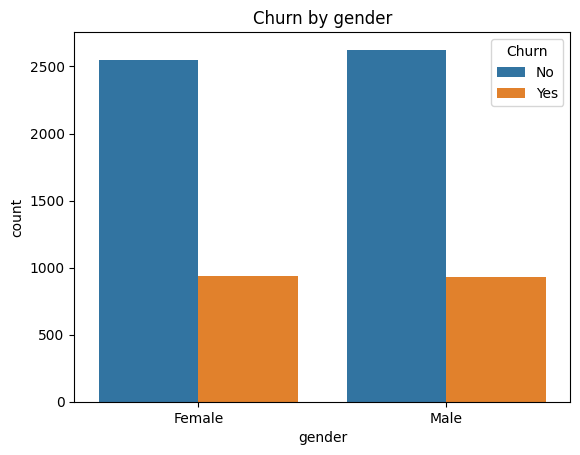

In [16]:
sns.countplot(x = df['gender'], data = df , hue = 'Churn')
plt.title("Churn by gender")
plt.show()

by looking above graph we can say that churn is not depends on gender

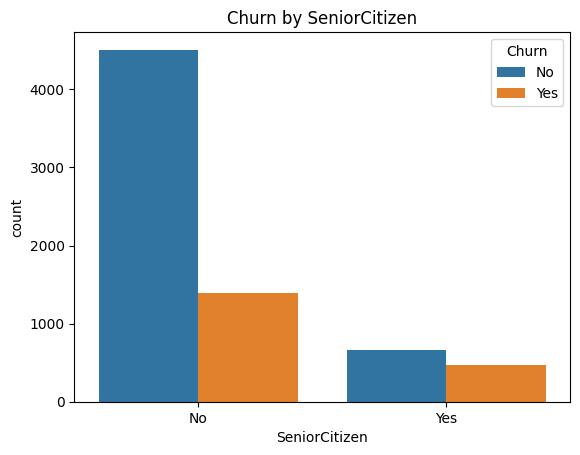

In [17]:
sns.countplot(x = df['SeniorCitizen'], data = df , hue = 'Churn')
plt.title("Churn by SeniorCitizen")
plt.show()

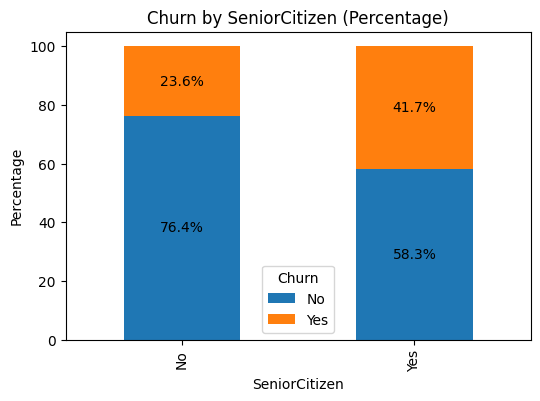

In [18]:

# Calculate the counts for each combination of SeniorCitizen and Churn
counts = df.groupby(['SeniorCitizen', 'Churn']).size().unstack()

# Calculate percentages of total
percentages = counts.div(counts.sum(axis=1), axis=0) * 100

# Plot the stacked bar chart
ax = percentages.plot(kind='bar', stacked=True, figsize=(6, 4))

# Add percentage labels on the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')

# Add titles and labels
plt.title('Churn by SeniorCitizen (Percentage)')
plt.ylabel('Percentage')
plt.xlabel('SeniorCitizen')

# Show the plot
plt.show()



comparative a greater pecentage of people in senior citizen category have churned

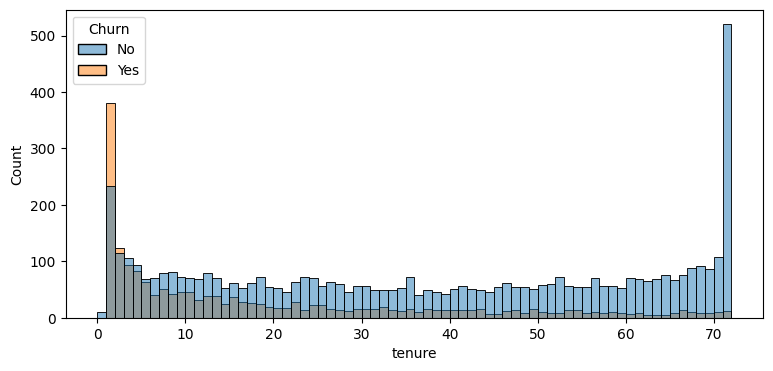

In [25]:
plt.figure(figsize = (9,4))
#hue is used to give filter
sns.histplot(x = 'tenure' , data = df, bins = 72 , hue = 'Churn')
plt.show()

The grey might be due to partial transparency of blue and orange bars together, resulting in a combined visual effect.
The grey part in the histogram likely repre... by Neha Sahu
Neha Sahu
The grey part in the histogram likely represents overlapping regions where both "Yes" and "No" churn values exist at the same time for specific tenure values. When the hues ("Yes" for churn, and "No" for no churn) are stacked in a bar chart, the grey areas can be the result of transparency or overlapping counts.
has context menu


dependent , independent
mean median relations , how to help in understanding data dis
handling categorical variables
relation b/w charges and churn(which graph/plot we will use for this

people who have used our services for a long time have stayed and people who have used our sevices
1 or 2 months have churned

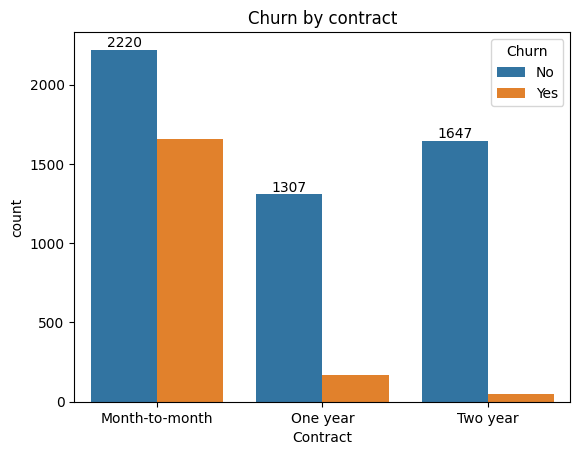

In [20]:
ax = sns.countplot(x=df['Contract'], data = df, hue = 'Churn')
ax.bar_label(ax.containers[0])
plt.title("Churn by contract")
plt.show()

people who have month to month contract are likely to churn then from those who have 1 or 2 years or contract.

In [ ]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

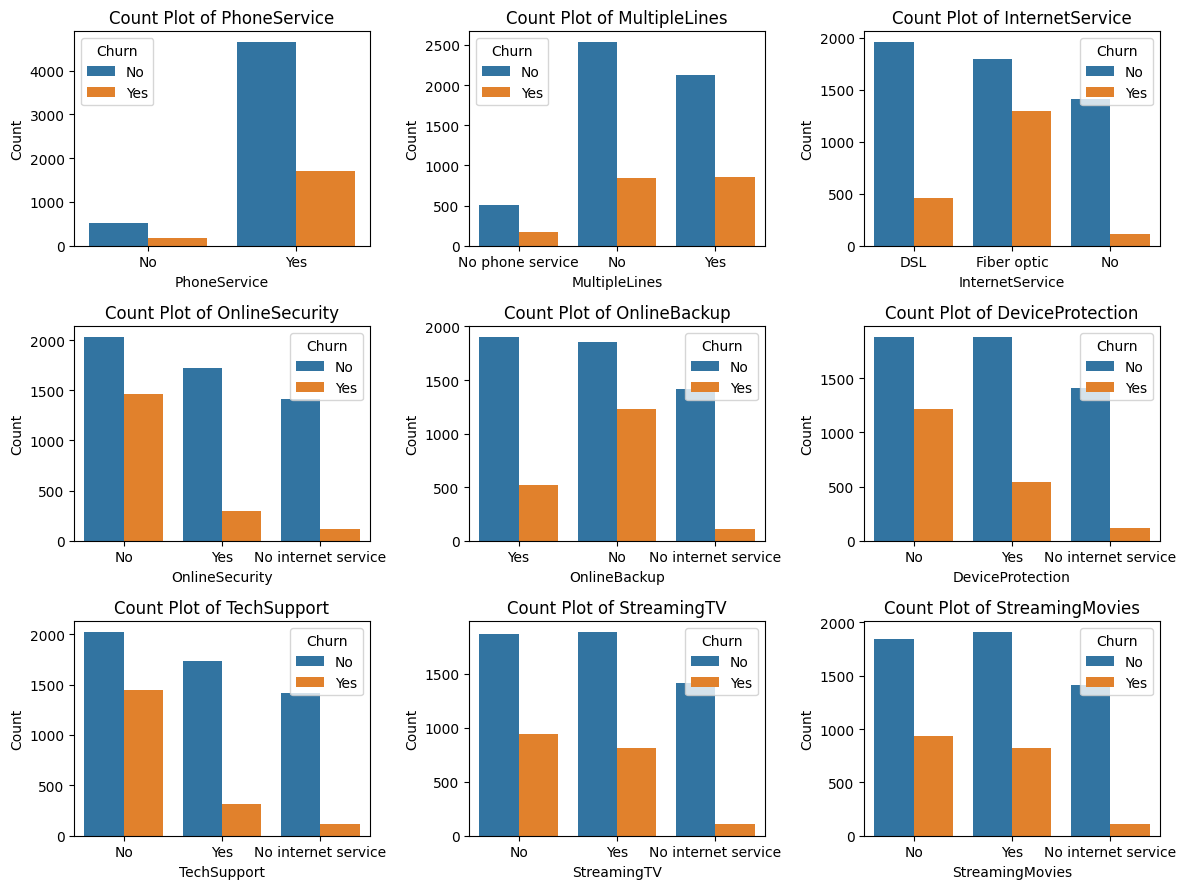

In [ ]:
columns = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
           'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Number of columns for the subplot grid
n_cols = 3
n_rows = (len(columns) + n_cols - 1) // n_cols  # Calculate number of rows needed

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 3))  # Adjust figsize as needed

# Flatten the axes array for easy iteration (handles both 1D and 2D arrays)
axes = axes.flatten()

# Iterate over columns and plot count plots
for i, col in enumerate(columns):
    sns.countplot(x=col, data=df, ax=axes[i], hue = df["Churn"])
    axes[i].set_title(f'Count Plot of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Remove empty subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

The majority of customers who do not churn tend to have services like PhoneService, InternetService (particularly DSL), and OnlineSecurity enabled. For services like OnlineBackup, TechSupport, and StreamingTV, churn rates are noticeably higher when these services are not used or are unavailable.

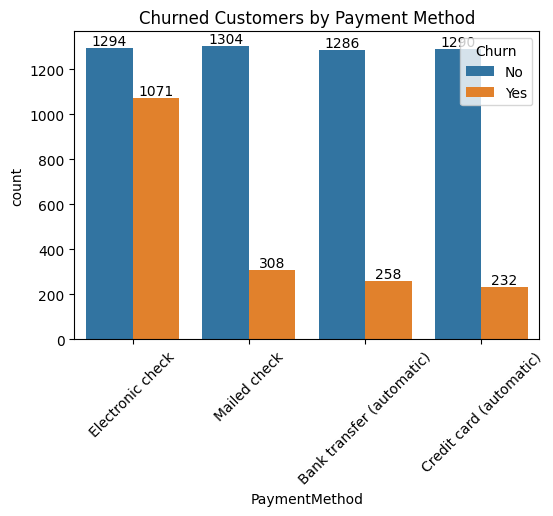

In [ ]:
plt.figure(figsize = (6,4))
ax = sns.countplot(x = "PaymentMethod", data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churned Customers by Payment Method")
plt.xticks(rotation = 45)
plt.show()

customer is likely to churn when he is using electronic check as a payment method.

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

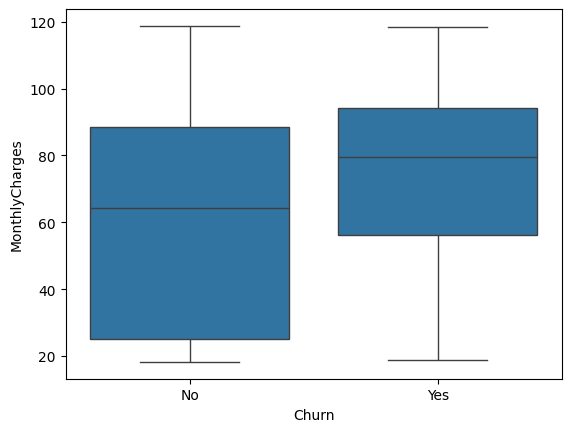

In [5]:
import seaborn as sns
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)


Customers with higher monthly charges are more likely to churn, with churned customers showing a higher median charge. Non-churned customers have a wider range of charges, while churned customers display a more consistent charge pattern. This suggests monthly charges could be a key factor in predicting churn.








<Axes: xlabel='Churn', ylabel='TotalCharges'>

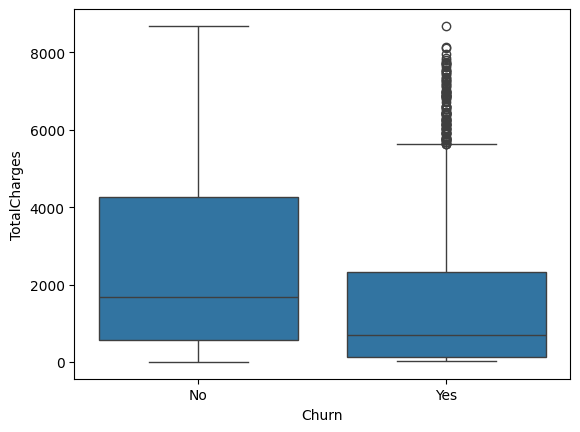

In [10]:
import seaborn as sns
sns.boxplot(x='Churn', y='TotalCharges', data=df)


Customers who churned generally have lower total charges, indicating that those with shorter tenures are more likely to leave. There are some outliers among churned customers with higher charges, but overall, non-churned customers have higher and more varied total charges. This suggests a correlation between tenure (or service usage) and churn likelihood.

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

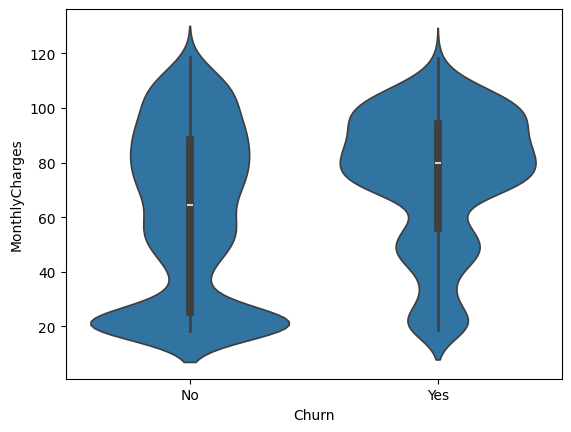

In [7]:
sns.violinplot(x='Churn', y='MonthlyCharges', data=df)


<Axes: xlabel='Churn', ylabel='TotalCharges'>

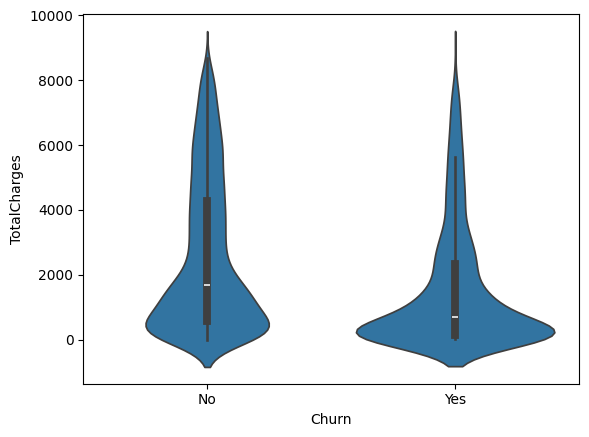

In [11]:
sns.violinplot(x='Churn', y='TotalCharges', data=df)


The violin plots show that customers who churn tend to have higher MonthlyCharges and a narrower distribution of TotalCharges compared to those who do not churn.

In [9]:
df['TotalCharges'].value_counts()

,count
TotalCharges,
0.00,11
20.20,11
19.75,9
20.05,8
19.90,8
...,...
6849.40,1
692.35,1
130.15,1
